In [18]:
import scipy.io
import networkx as nx 
import bct 
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import collections

# Preparation of dataset for use
number_subjects = 9
number_ROIs = pd.DataFrame(data = {'dsk': [68], 'dstrx': [148]})

# definition of directory with dataset
dir_fmri_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_desikan/'
dir_fmri_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_destrieux/'

dir_eeg_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_desikan/'
dir_eeg_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_destrieux/'


### Script for the initial analysis of the average graph - each subject independently and all combined

In [2]:
#1.Creation of average Graph 
def createAvGraph(file,data_type):
    
    # Load Matlab file with connectivity matrix for each time point - 3D matrix
    mat = scipy.io.loadmat(file)

    if data_type == 'fmri':
        conn_matrix = mat['connFMRI'].transpose() #connectivity fMRI matrix with numpy format
    elif data_type == 'eeg': #for now only for broad band TODO others !
        conn_matrix = mat['connEEGbroad'].transpose() #connectivity EEG matrix with numpy format
    elif data_type == 'eeg_alpha':
        conn_matrix = mat['connEEGalpha'].transpose()
    elif data_type == 'eeg_beta':
        conn_matrix = mat['connEEGbeta'].transpose()
    elif data_type == 'eeg_delta':
        conn_matrix = mat['connEEGdelta'].transpose()
    elif data_type == 'eeg_gamma':
        conn_matrix = mat['connEEGgamma'].transpose()
    elif data_type == 'eeg_theta':
        conn_matrix = mat['connEEGtheta'].transpose()
        
    t_points = conn_matrix.shape[0] # number of layers of multilayer matrix
    num_areas = conn_matrix.shape[1] #number of nodes of the graph
    
    # Get average connectivity matrix
    av_conn = np.zeros((num_areas,num_areas))
       
    for i in range(t_points):
        
        av_conn = av_conn + conn_matrix[i]
            
    av_conn = av_conn/t_points 
    
    G = nx.from_numpy_matrix(av_conn)
    
    return G


In [3]:
# 2. Threshold graph with given proportion

def thresholdGraph(G, threshold, type_data, atlas):
    
    if(type_data == 'fmri'):
        # get absolute value connectivity matrix
        conn_matrix = abs(nx.to_numpy_array(G))
    else:
        conn_matrix = nx.to_numpy_array(G)
    # to threshold graph keeping top X% of the edges
    new = bct.utils.threshold_proportional(conn_matrix, threshold, True)
    
    #for the fMRI data we need to recover non-absolute values as Phase Coherence is between -1 and 1
    if(type_data == 'fmri'):
        
        ind_keep = np.transpose(np.nonzero(new))
        new = np.zeros((number_ROIs.iloc[0][atlas], number_ROIs.iloc[0][atlas]))
        min_positive = 1 #to store minimum positive value kept of phase coherence
        max_negative = -1 #to store maximum negative value kept of phase coherence
        
        for ind in ind_keep:
            #print(nx.to_numpy_array(G)[ind[0],ind[1]])
            new[ind[0],ind[1]] = nx.to_numpy_array(G)[ind[0],ind[1]]
            #print(new[ind[0],ind[1]])
            if nx.to_numpy_array(G)[ind[0],ind[1]] > 0 and nx.to_numpy_array(G)[ind[0],ind[1]] < min_positive:
                min_positive = nx.to_numpy_array(G)[ind[0],ind[1]]
            elif nx.to_numpy_array(G)[ind[0],ind[1]] < 0 and nx.to_numpy_array(G)[ind[0],ind[1]] > max_negative:
                max_negative = nx.to_numpy_array(G)[ind[0],ind[1]]
        
        G_new = nx.from_numpy_matrix(new)
        
        return G_new, min_positive, max_negative
    
    else:
        min_coh = np.amin(new) #to store minimum value kept of imaginary part of coherency
        G_new = nx.from_numpy_matrix(new)
        
        return G_new, min_coh 

In [9]:
#testing code box

G_av = createAvGraph(dir_fmri_desikan + 'subj03-7T/conn_desi_phase_coh_time_fmri.mat', 'fmri')

[G_av_thr, min_positive, max_negative] = thresholdGraph(G_av, 0.1, 'fmri', 'dsk')

print("The minimum positive value of Phase Coherence kept is:", min_positive)
print("The maximum negative value of Phase Coherence kept is:", max_negative)

The minimum positive value of Phase Coherence kept is: 0.387151320538
The maximum negative value of Phase Coherence kept is: -0.392674958388


In [31]:
#3. Degree analysis functions 

#Average Degree
def averageDegree(G):
    
    E = G.number_of_edges()
    N = G.number_of_nodes()
    av_degree = (2*E)/N
    
    return av_degree

#Average Weighted Degree
def averageWeightedDegree(G):
    
    N = G.number_of_nodes()
    weightedDegree = np.zeros(N)
    #we start by computing the weighted degree for each node (sum of weights of the edges linked to that node        
    for u, v, w in G.edges(data = 'weight'):
        #add weight to both nodes that share the edge
        weightedDegree[u] += w
        weightedDegree[v] += w
    av_weightedDegree = sum(weightedDegree)/N
    
    return [weightedDegree, av_weightedDegree]

#Degree Distribution - obtain plot of histogram, degree distribution and cumulative degree distribution
def degreeDistribution(G, atlas):
    
    #get sequence of the degrees of each node ordered 
    degree_sequence = sorted([d for n, d in G.degree()], reverse=True) 
    
    plt.figure() 
    plt.hist(degree_sequence, bins=10, rwidth=0.4)
    plt.xticks(np.arange(0, (number_ROIs.iloc[0][atlas])*0.5, 5))
    plt.title("Degree Histrogram")
    plt.ylabel("Number of nodes")
    plt.xlabel("k")
    
    degreeCount = collections.Counter(degree_sequence) #gives series with degree and number of times it repeats
    degree, count = zip(*degreeCount.items()) #to obtain arguments separated 
    count = list(count)
    N = G.number_of_nodes()
    
    # normalize count to obtain P(k)
    for i in range(len(count)):
        count[i] = count[i]/N
    
    count_cum = []
    for i in range(len(count)):
        count_cum += [sum(count[0:i+1])] #append each cum_sum to the list

    plt.figure()
    plt.loglog(degree, count_cum, 'o') #plot with log scaling on both axis
    plt.title("Cumulative Degree Distribution with log-log scale")
    plt.ylabel("log₁₀ Pcum(k)")
    plt.xlabel("log₁₀ k")


In [ ]:
# 4. Small-world metrics

#Getting average path length for every connected component in real graph - not fully connected as we applied a threshold
def averagePathLength(G):
    
    path_length_sum = 0
    graph_components = sorted(nx.connected_components(G), key=len, reverse=True)
    
    for i in range(0,len(graph_components):
        g = G.subgraph(graph_components[i]).copy()
        shortest_path_g = nx.average_shortest_path_length(g)
        path_length_sum += shortest_path_g
                   
        print("Average path lenght of connected component ", i , ", having ", g.number_of_nodes(), " nodes: ", shortest_path_g)
                   
    print("Number of connected components:", len(graph_components))
    average_path_length = path_length_sum/len(graph_components)
    
    return average_path_length
                   
#Finding average clustering coeficient
clustering_coefficient = nx.average_clustering(G_av_thr)
print("Clustering coefficient: ", clustering_coefficient)

APL = averagePathLength(G_av_thr)
print("Total average path length ", APL)

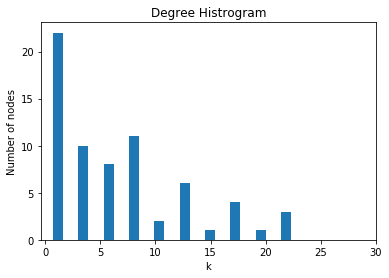

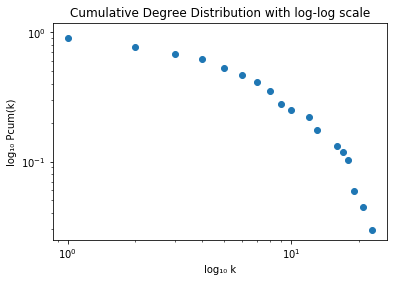

In [32]:
degreeDistribution(G_av_thr, 'dsk')